# Phase 4: Model Training

This notebook trains and compares classification models for customer churn
prediction using the processed dataset produced by
`02_data_preprocessing_feature_engineering.ipynb`.

**Objectives**
- Load the processed train / test datasets
- Train multiple classification models (Logistic Regression, Decision Tree,
  Random Forest, Gradient Boosting)
- Compare model performance, using ROC AUC as the primary metric
- Hyperparameter-tune the Random Forest and select a prediction threshold
- Save the final model and a training report

**Workflow note:** Gradient Boosting wins the initial comparison with default
hyperparameters. The workflow then tunes the Random Forest and saves it as the
final production model; the best default model is also persisted for
reference.

## 1. Setup

In [1]:
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint

from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

DATA_DIR = "../data/processed"
MODELS_DIR = "../models"
REPORTS_DIR = "../reports"

X_TRAIN_CSV = os.path.join(DATA_DIR, "X_train.csv")
X_TEST_CSV = os.path.join(DATA_DIR, "X_test.csv")
Y_TRAIN_CSV = os.path.join(DATA_DIR, "y_train.csv")
Y_TEST_CSV = os.path.join(DATA_DIR, "y_test.csv")

CHURN_PREDICTION_MODEL_PKL = os.path.join(MODELS_DIR, "churn_prediction_model.pkl")
FINAL_MODEL_PKL = os.path.join(MODELS_DIR, "final_churn_model.pkl")
BEST_THRESHOLD_PKL = os.path.join(MODELS_DIR, "best_threshold.pkl")

MODEL_COMPARISON_CSV = os.path.join(REPORTS_DIR, "model_comparison.csv")
TRAINING_SUMMARY_CSV = os.path.join(REPORTS_DIR, "training_summary.csv")

## 2. Load Processed Datasets

In [2]:
X_train = pd.read_csv(X_TRAIN_CSV)
X_test = pd.read_csv(X_TEST_CSV)

y_train = pd.read_csv(Y_TRAIN_CSV).squeeze()
y_test = pd.read_csv(Y_TEST_CSV).squeeze()

print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape} | y_test  : {y_test.shape}")

X_train : (5634, 51) | y_train : (5634,)
X_test  : (1409, 51) | y_test  : (1409,)


## 3. Model Evaluation Function

In [3]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    results = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC AUC": roc_auc_score(y_test, probabilities)
    }

    return results

## 4. Train and Compare Models

In [4]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [5]:
results = []

for name, model in models.items():
    metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
    metrics["Model"] = name
    results.append(metrics)

In [6]:
results_df = pd.DataFrame(results)
results_df = results_df[["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]]
results_df = results_df.sort_values(by="ROC AUC", ascending=False)

results_df.to_csv(MODEL_COMPARISON_CSV, index=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,Gradient Boosting,0.799858,0.652318,0.526738,0.582840,0.852257
0,Logistic Regression,0.801278,0.647799,0.550802,0.595376,0.849319
2,Random Forest,0.791341,0.634228,0.505348,0.562500,0.833411
1,Decision Tree,0.737402,0.505291,0.510695,0.507979,0.664773


Gradient Boosting achieves the highest ROC AUC, closely followed by the
Random Forest. Because the classes are imbalanced, ROC AUC is a more reliable
comparison metric than accuracy. The workflow proceeds by tuning the Random
Forest and saving it as the final model.

## 5. Best Default Model (Gradient Boosting)

In [7]:
best_model_name = results_df.iloc[0]["Model"]
print("Best default model:", best_model_name)

best_model = models[best_model_name]
best_model.fit(X_train, y_train)

Best default model: Gradient Boosting


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [8]:
predictions = best_model.predict(X_test)
cm = confusion_matrix(y_test, predictions)
cm

array([[930, 105],
       [177, 197]])

In [9]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## 6. Cross-Validation (Gradient Boosting)

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="roc_auc")

print("Fold scores:", scores.round(4))
print("Mean ROC AUC:", round(scores.mean(), 4))

Fold scores: [0.8574 0.846  0.8598 0.8713 0.8755]
Mean ROC AUC: 0.862


## 7. Save the Best Default Model

In [11]:
joblib.dump(best_model, CHURN_PREDICTION_MODEL_PKL)
print("Saved:", os.path.exists(CHURN_PREDICTION_MODEL_PKL))

Saved: True


## 8. Initial Model Summary

In [12]:
summary = {
    "Training Samples": X_train.shape[0],
    "Testing Samples": X_test.shape[0],
    "Features": X_train.shape[1],
    "Best Default Model": best_model_name,
    "Best Default ROC AUC": round(results_df.iloc[0]["ROC AUC"], 4)
}

pd.DataFrame(summary.items(), columns=["Metric", "Value"])

,Metric,Value
0,Training Samples,5634
1,Testing Samples,1409
2,Features,51
3,Best Default Model,Gradient Boosting
4,Best Default ROC AUC,0.8523


## 9. Hyperparameter Tuning (Random Forest)

In [13]:
rf_params = {
    "n_estimators": randint(100, 500),
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [14]:
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Al

In [15]:
rf_search.best_params_

{'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'n_estimators': 230}

In [16]:
print("Best Cross-Validation ROC AUC:", round(rf_search.best_score_, 4))

Best Cross-Validation ROC AUC: 0.8602


## 10. Tuned Random Forest Evaluation

In [17]:
final_model_name = "Random Forest"
best_rf = rf_search.best_estimator_

predictions = best_rf.predict(X_test)
probabilities = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, predictions))
print("Test ROC AUC:", round(roc_auc_score(y_test, probabilities), 4))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

Test ROC AUC: 0.853


## 11. ROC Curve (Tuned Random Forest)

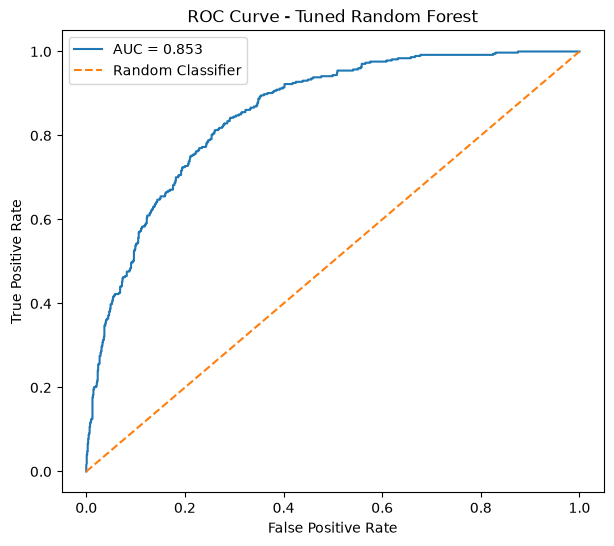

In [18]:
fpr, tpr, _ = roc_curve(y_test, probabilities)
auc = roc_auc_score(y_test, probabilities)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.show()

## 12. Precision-Recall Curve (Tuned Random Forest)

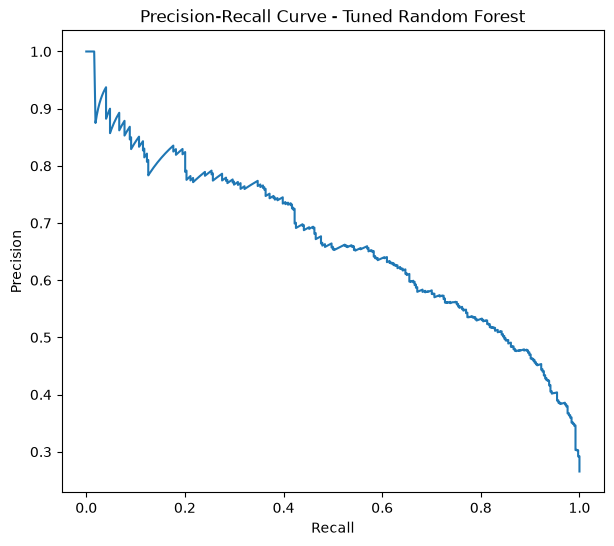

In [19]:
precision, recall, _ = precision_recall_curve(y_test, probabilities)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Tuned Random Forest")
plt.show()

## 13. Feature Importance (Tuned Random Forest)

In [20]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.head(20)

,Feature,Importance
38,cat__Contract_Month-to-month,0.109800
0,num__Tenure Months,0.108875
2,num__Total Charges,0.086351
3,num__Avg Monthly Spend,0.065312
1,num__Monthly Charges,0.064103
20,cat__Online Security_No,0.051403
29,cat__Tech Support_No,0.048466
18,cat__Internet Service_Fiber optic,0.046706
49,cat__Customer Age Group_New,0.044962
10,cat__Dependents_No,0.035103


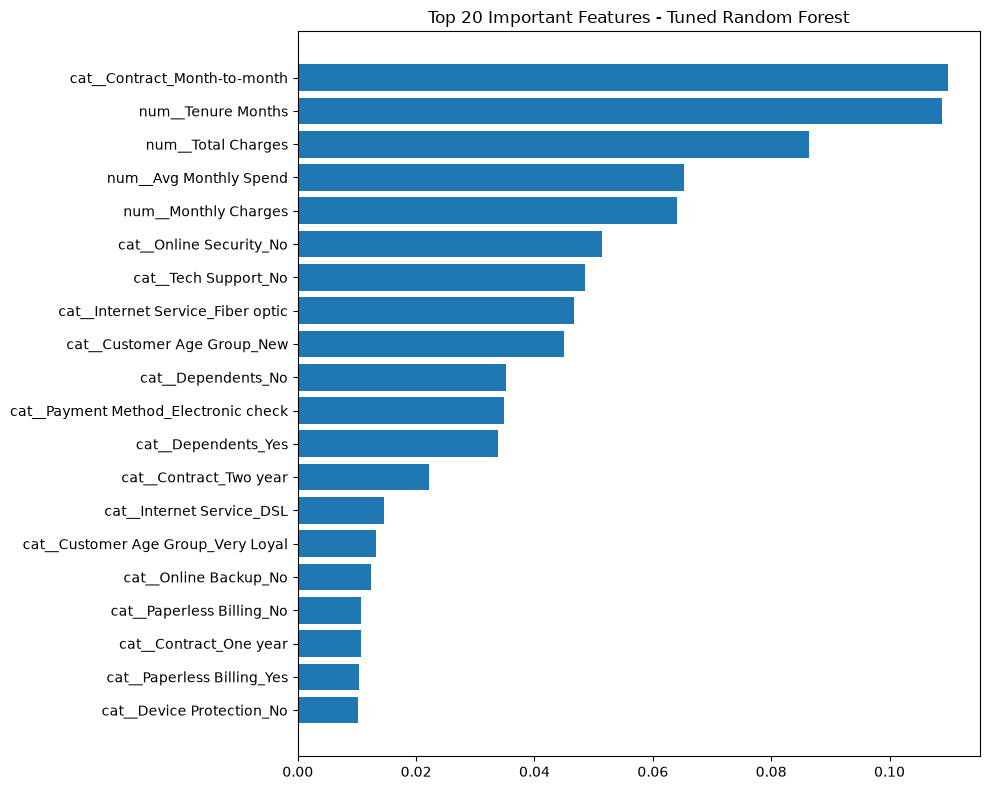

In [21]:
plt.figure(figsize=(10, 8))
plt.barh(importance.head(20)["Feature"], importance.head(20)["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features - Tuned Random Forest")
plt.tight_layout()
plt.show()

## 14. Threshold Optimization (Tuned Random Forest)

The default decision threshold of 0.5 can be suboptimal for imbalanced data.
This section searches for the threshold that maximizes the F1 score.

**Methodology note:** the threshold is selected on the test set, which can make
the resulting metrics slightly optimistic. In practice the threshold should be
tuned on a held-out validation set before deployment.

In [22]:
thresholds = np.arange(0.30, 0.81, 0.05)

threshold_results = []
for threshold in thresholds:
    preds = (probabilities >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1
0,0.30,0.537175,0.772727,0.633772
1,0.35,0.570526,0.724599,0.638398
2,0.40,0.592857,0.665775,0.627204
3,0.45,0.633333,0.609626,0.621253
4,0.50,0.658940,0.532086,0.588757
5,0.55,0.693277,0.441176,0.539216
6,0.60,0.750000,0.368984,0.494624
7,0.65,0.777778,0.280749,0.412574
8,0.70,0.779817,0.227273,0.351967
9,0.75,0.828947,0.168449,0.280000


In [23]:
best_threshold = threshold_df.loc[threshold_df["F1"].idxmax()]
best_threshold

Threshold    0.350000
Precision    0.570526
Recall       0.724599
F1           0.638398
Name: 1, dtype: float64

## 15. Save the Final Model (Tuned Random Forest)

In [24]:
joblib.dump(best_rf, FINAL_MODEL_PKL)
joblib.dump(best_threshold, BEST_THRESHOLD_PKL)

print("Final model saved    :", os.path.exists(FINAL_MODEL_PKL))
print("Best threshold saved :", os.path.exists(BEST_THRESHOLD_PKL))

Final model saved    : True
Best threshold saved : True


## 16. Final Training Report

In [25]:
training_report = {
    "Best Model": final_model_name,
    "Cross Validation AUC": round(rf_search.best_score_, 4),
    "Test ROC AUC": round(roc_auc_score(y_test, probabilities), 4),
    "Best Threshold": round(float(best_threshold["Threshold"]), 2),
    "Precision": round(float(best_threshold["Precision"]), 4),
    "Recall": round(float(best_threshold["Recall"]), 4),
    "F1 Score": round(float(best_threshold["F1"]), 4)
}

report_df = pd.DataFrame(training_report.items(), columns=["Metric", "Value"])
report_df

,Metric,Value
0,Best Model,Random Forest
1,Cross Validation AUC,0.8602
2,Test ROC AUC,0.853
3,Best Threshold,0.35
4,Precision,0.5705
5,Recall,0.7246
6,F1 Score,0.6384


In [26]:
report_df.to_csv(TRAINING_SUMMARY_CSV, index=False)
print("Saved:", os.path.exists(TRAINING_SUMMARY_CSV))

Saved: True
